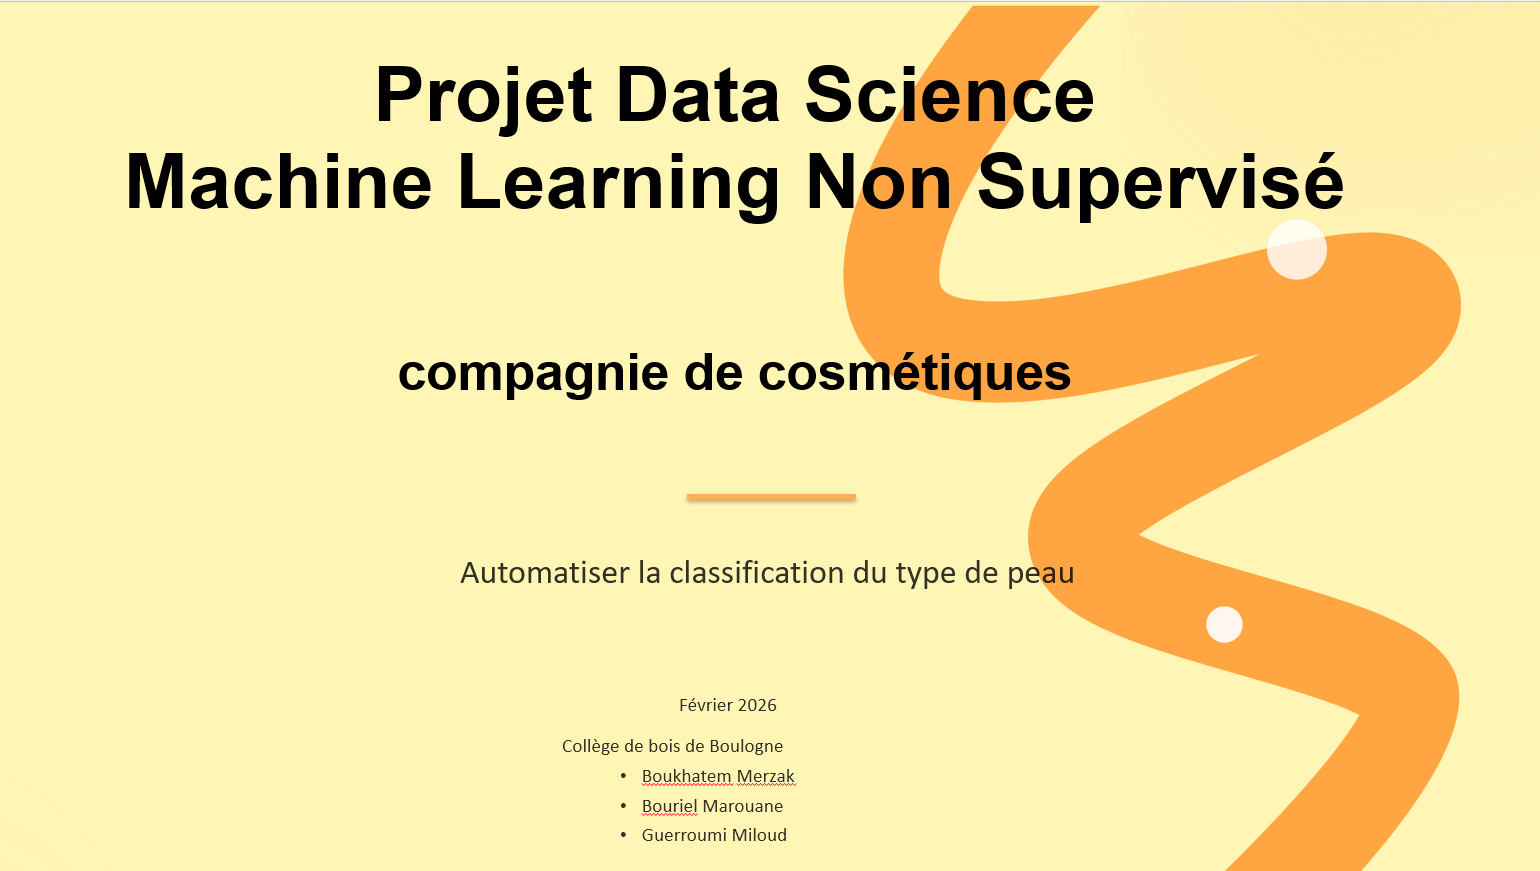

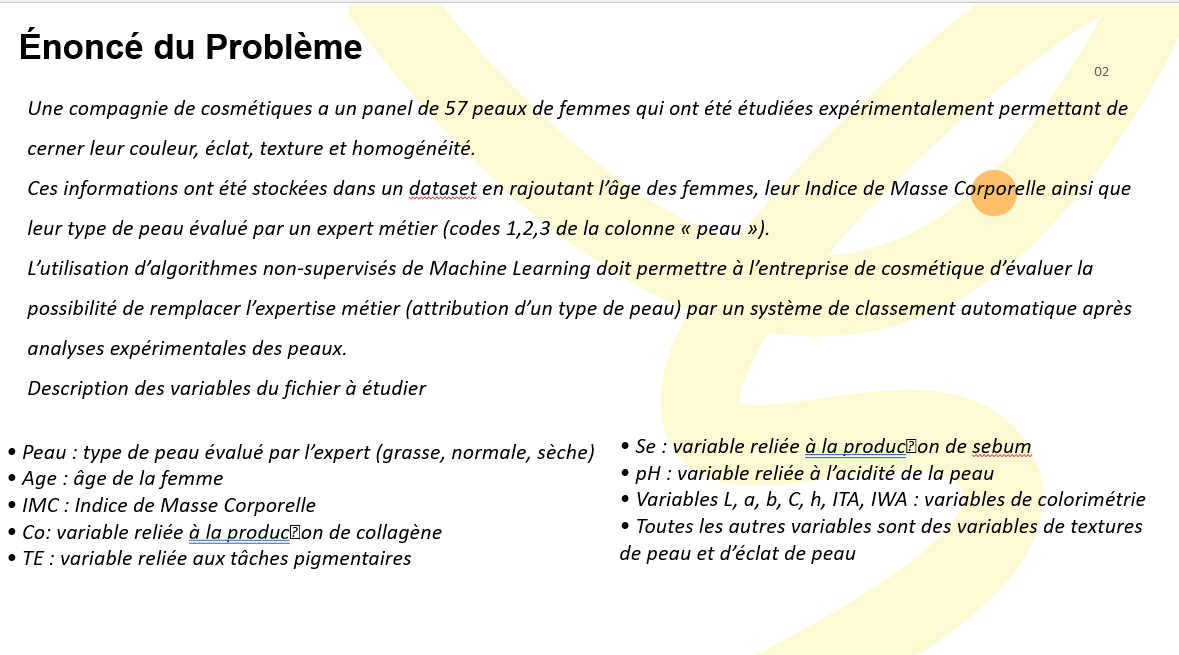

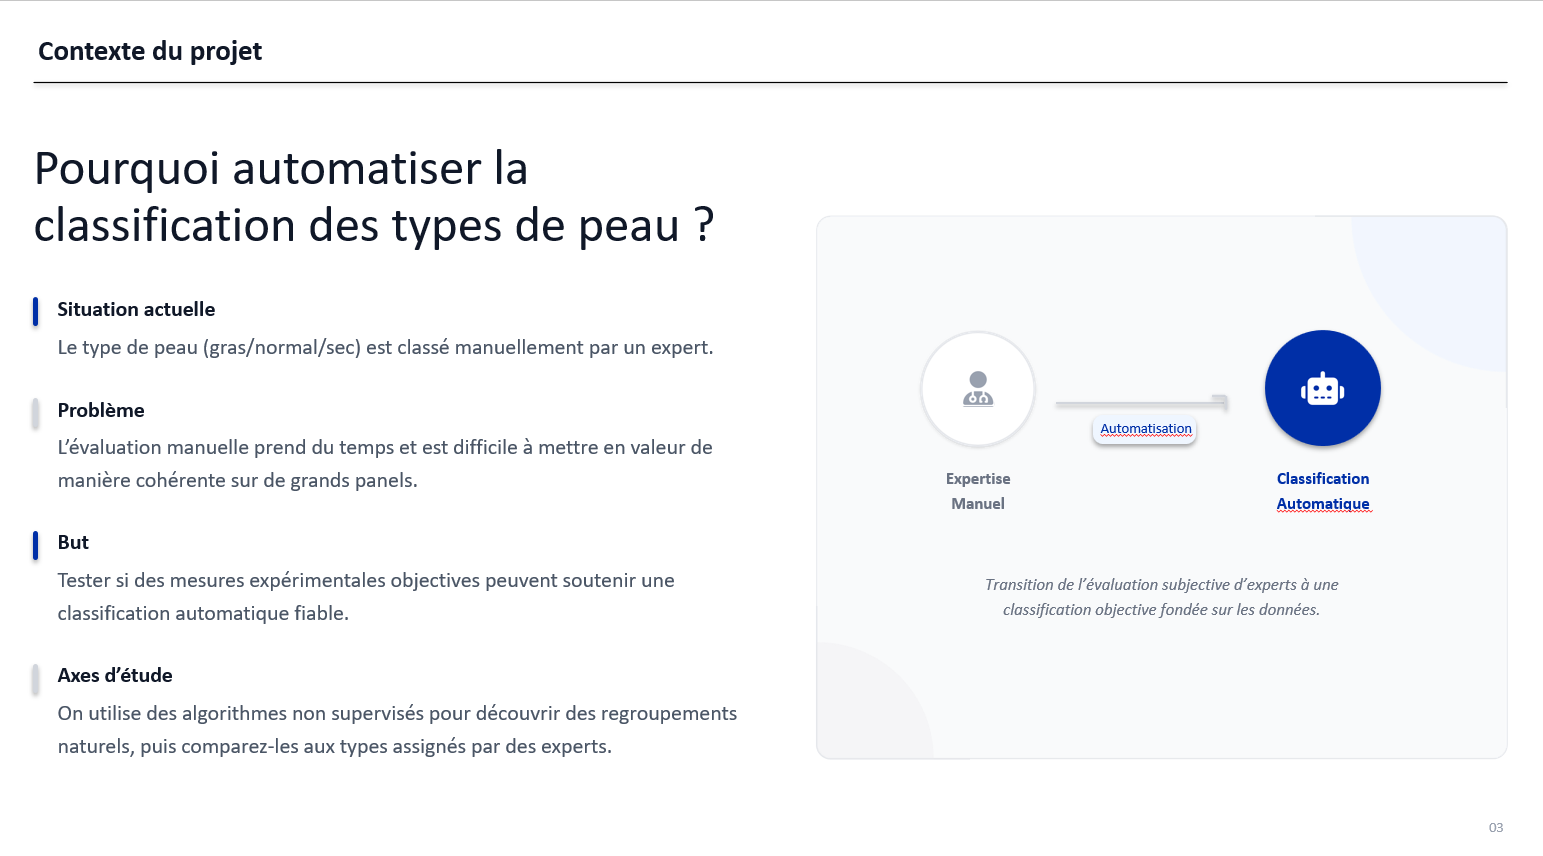

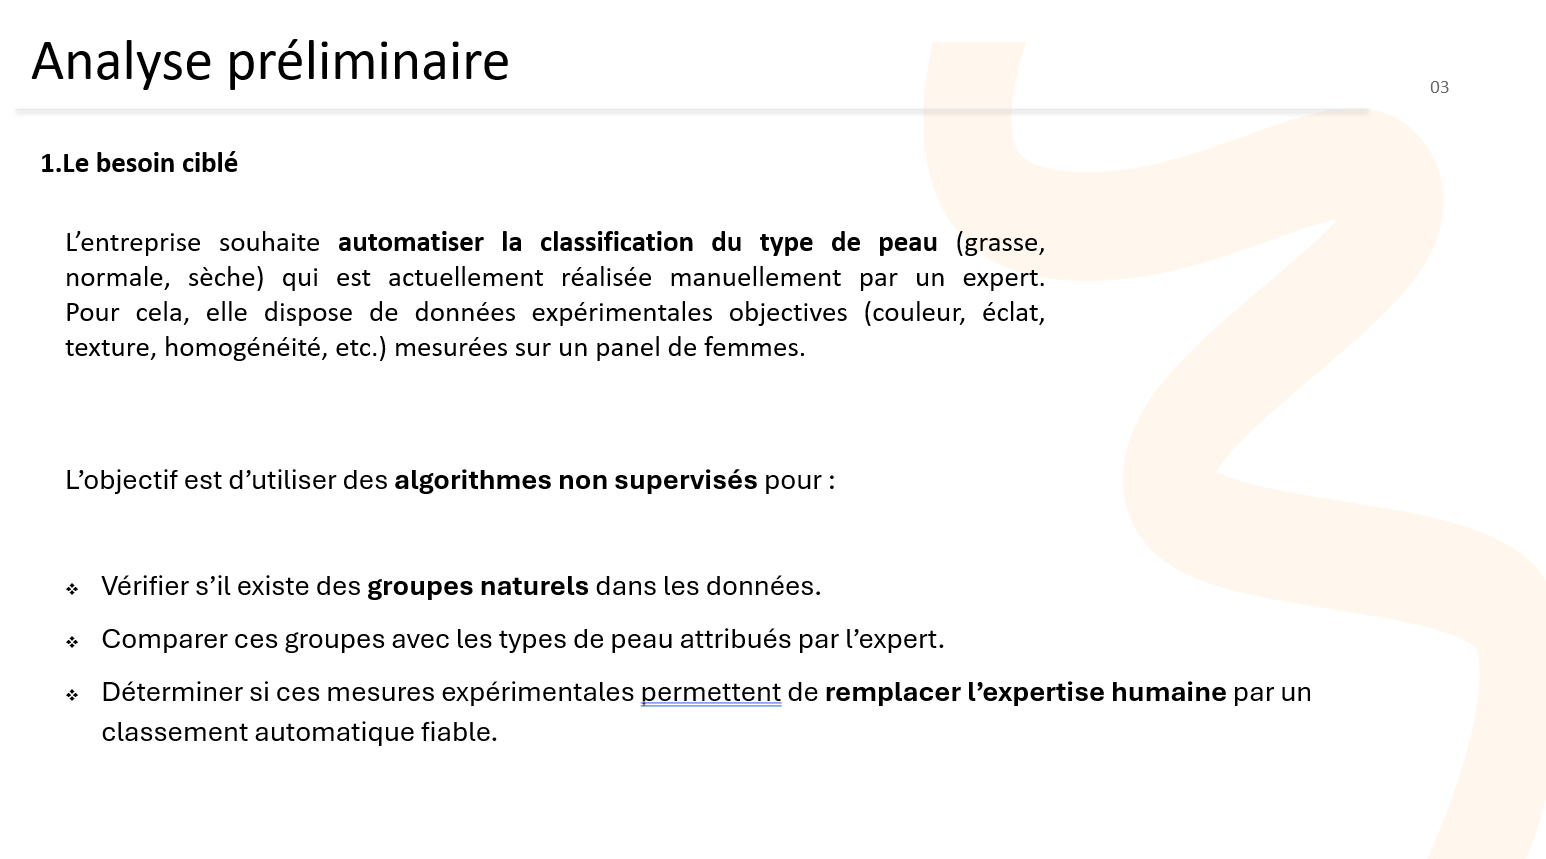

# **.	Étapes à suivre**

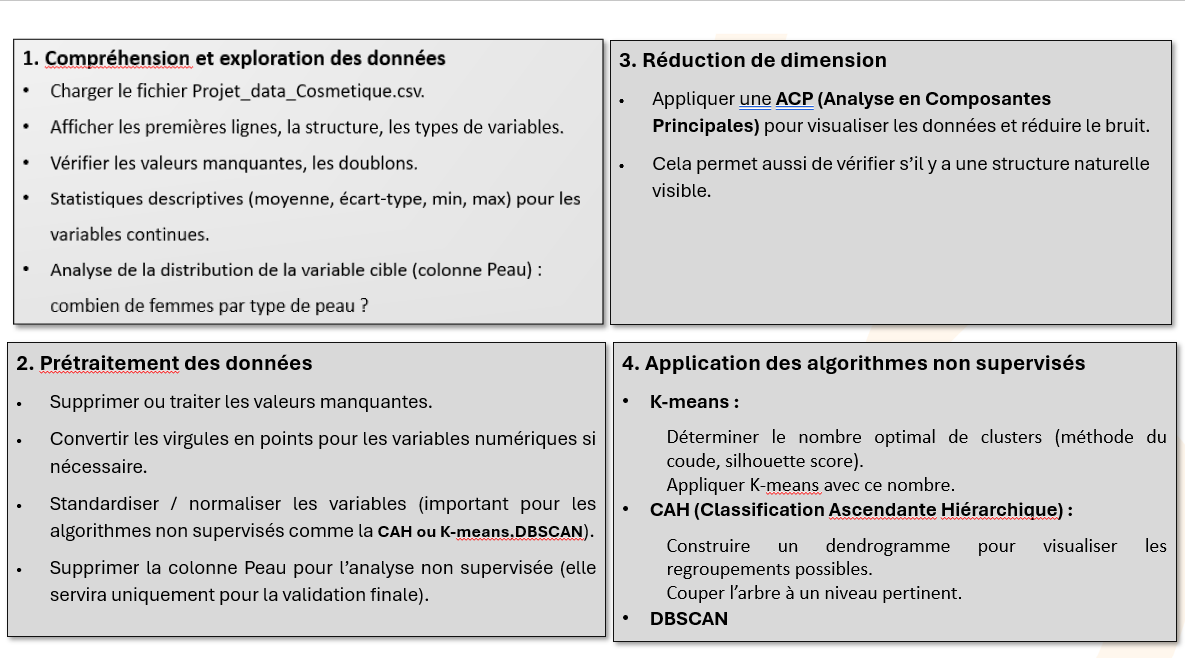

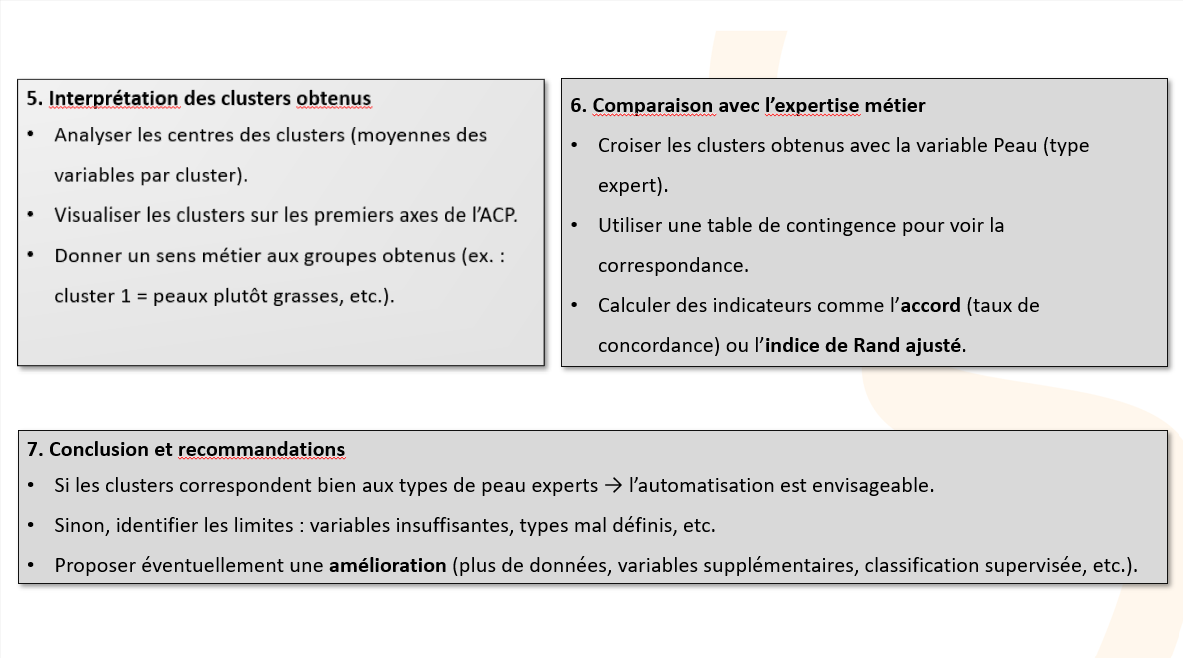

# **Traitement en Détail**

## **Import des librairies et configuration**

In [1]:
# ============================================
# ÉTAPE 0 : IMPORT DES LIBRAIRIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import f_classif

# Scipy pour la CAH
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")


## **Étape 1 : Chargement et nettoyage des données**

In [2]:

# a Chargement
df_raw = pd.read_csv('Projet_data_Cosmetique.csv', sep=';', decimal=',')

print("-----> DONNÉES BRUTES :")
print(f"Shape: {df_raw.shape}")
print('\n--------------------------------------')
print(f"Colonnes: {df_raw.columns.tolist()}")

# b Nettoyage des noms de colonnes
df_raw.columns = df_raw.columns.str.strip()  # Enlève les espaces
df_raw.columns = df_raw.columns.str.replace(' ', '_')  # Remplace espaces par _

print('\n-------------------------------------------------------------------------------')
print(f" Colonnes nettoyées:")
print(df_raw.columns.tolist())

print('-------------------------------------------------------------------------------')
# c Aperçu
print("\n5 lignes:")
df_raw.sample(5)

-----> DONNÉES BRUTES :
Shape: (58, 72)

--------------------------------------
Colonnes: ['Code', 'Peau', 'Age', 'IMC ', 'Co', 'Se', 'TE', 'pH', 'L_front', 'a_front', 'b_front', 'C_front', 'h_front', 'ITA_front', 'IWA_front', 'Front_aire_porphy', 'Front_int_porphy', 'Front_Lightness', 'Front_Spec_Bright', 'Front_Global_Bright', 'Front_aire_pacnes', 'Front_int_pacnes', 'Front_nb_pts_pacnes', 'L_contrast', 'L_energy', 'L_correlation', 'L_homogeneity', 'L_localentropy', 'a_contrast', 'a_energy', 'a_correlation', 'a_homogeneity', 'a_localentropy', 'b_contrast', 'b_energy', 'b_correlation', 'b_homogeneity', 'b_localentropy', '274_0_0657', '283_0_1145', '301_0_1183', '301_0_1742', '301_0_2078', '311_0_1361', '329_0_1371', '330_0_1371', '355_0_1760', '456_0_2205', '469_0_2218', '470_02271', '484_0_2264', '484_0_2423', '498_0_2431', '498_0_2498', '498_0_2541', '521_0_1274', '633_0_3740', '638_0_3681', '334_13_828', '335_19_357', '507_44_556', '557_34_1693', '602_49_1698', '638_61_427', '691_5

,Code,Peau,Age,IMC,Co,Se,TE,pH,L_front,a_front,b_front,C_front,h_front,ITA_front,IWA_front,Front_aire_porphy,Front_int_porphy,Front_Lightness,Front_Spec_Bright,Front_Global_Bright,Front_aire_pacnes,Front_int_pacnes,Front_nb_pts_pacnes,L_contrast,L_energy,L_correlation,L_homogeneity,L_localentropy,a_contrast,a_energy,a_correlation,a_homogeneity,a_localentropy,b_contrast,b_energy,b_correlation,b_homogeneity,b_localentropy,274_0_0657,283_0_1145,301_0_1183,301_0_1742,301_0_2078,311_0_1361,329_0_1371,330_0_1371,355_0_1760,456_0_2205,469_0_2218,470_02271,484_0_2264,484_0_2423,498_0_2431,498_0_2498,498_0_2541,521_0_1274,633_0_3740,638_0_3681,334_13_828,335_19_357,507_44_556,557_34_1693,602_49_1698,638_61_427,691_59_1706,849_68_1637,850_71_1637,878_71_1622,1190_11_268,1199_244,1273_84_262,1288_18_259
44,V48,1,27,21.400,34.667,56.500,13.800,5.050,57.204,14.921,23.526,27.859,57.616,17.026,64.034,0.007,0.270,242,0.003,0.459,0.016,0.868,0.000,4.062,0.130,0.749,0.469,2684242.096,2.920,0.211,0.236,0.505,2420847.837,2.995,0.221,0.328,0.518,2399449.560,2.627,2.068,2.178,2.363,3.075,1.115,2.437,2.716,2.910,1.835,1.860,2.185,2.477,1.594,2.448,2.267,1.001,2.712,1.953,2.027,1.167,1.080,3.295,0.641,0.878,1.388,1.673,1.295,1.142,1.247,1.848,1.961,1.758,1.693
48,V52,1,23,22.100,39.000,87.500,12.450,4.750,65.260,10.942,15.367,18.864,54.547,44.800,73.877,0.032,2.220,248,0.002,0.180,0.045,5.727,0.001,3.737,0.167,0.505,0.480,2618169.501,3.429,0.196,0.402,0.497,2462612.743,2.419,0.234,0.296,0.545,2273798.577,2.839,2.839,2.867,2.764,3.265,2.441,2.813,2.788,3.344,1.800,2.104,2.124,2.353,1.649,2.162,2.056,1.203,3.441,1.967,2.022,2.558,2.725,4.427,1.329,1.566,4.090,2.439,1.246,1.804,1.063,2.827,2.736,3.313,3.010
26,V30,2,30,18.100,70.333,70.000,11.300,5.200,50.388,15.722,24.491,29.103,57.303,0.907,59.990,0.010,0.393,249,0.010,0.120,0.014,0.801,0.000,2.604,0.113,0.923,0.520,2379969.129,2.502,0.219,0.448,0.538,2202513.649,1.718,0.289,0.316,0.608,1924223.214,2.897,2.713,2.258,2.699,1.357,2.521,1.727,2.263,2.202,2.206,2.477,2.720,2.530,2.166,2.559,2.261,1.400,2.877,2.239,1.882,2.149,2.633,3.656,0.983,0.890,3.172,1.353,1.373,1.766,1.476,2.869,2.965,2.853,2.797
20,V23,2,18,22.200,64.333,123.000,12.400,4.650,48.327,17.341,26.423,31.605,56.723,-3.624,56.815,0.055,2.322,243,0.014,0.405,0.031,1.599,0.001,4.018,0.115,0.842,0.461,2728227.459,2.490,0.252,0.300,0.546,2243052.438,2.859,0.226,0.316,0.522,2372457.942,2.103,1.841,2.090,2.188,2.872,1.881,2.414,2.470,3.003,1.658,1.988,1.892,2.038,1.417,1.971,1.750,0.776,2.210,1.541,1.429,2.335,1.650,3.040,0.930,0.950,2.409,1.427,3.633,3.843,3.126,2.148,2.171,2.344,2.164
12,V14,3,28,22.700,51.333,46.500,11.250,4.900,54.966,15.831,19.291,24.955,50.627,14.436,65.581,0.010,0.439,251,0.002,0.069,0.013,0.704,0.001,4.433,0.110,0.854,0.444,2780655.311,4.506,0.176,0.394,0.448,2637079.953,3.371,0.202,0.293,0.500,2430982.440,3.062,2.957,1.802,1.741,2.873,2.899,2.824,2.781,1.357,1.804,2.284,1.973,2.599,1.695,1.044,2.039,0.996,3.404,2.422,2.450,1.590,2.295,2.239,1.365,1.657,3.345,2.259,1.643,1.813,1.501,3.109,3.133,3.259,3.126


## **Étape 2 : Analyse des valeurs manquantes**

VALEURS MANQUANTES :
           Colonne  Nb_NaN  Pourcentage
23      L_contrast       1        1.724
24        L_energy       1        1.724
25   L_correlation       1        1.724
26   L_homogeneity       1        1.724
27  L_localentropy       1        1.724
28      a_contrast       1        1.724
29        a_energy       1        1.724
30   a_correlation       1        1.724
31   a_homogeneity       1        1.724
32  a_localentropy       1        1.724
33      b_contrast       1        1.724
34        b_energy       1        1.724
35   b_correlation       1        1.724
36   b_homogeneity       1        1.724
37  b_localentropy       1        1.724


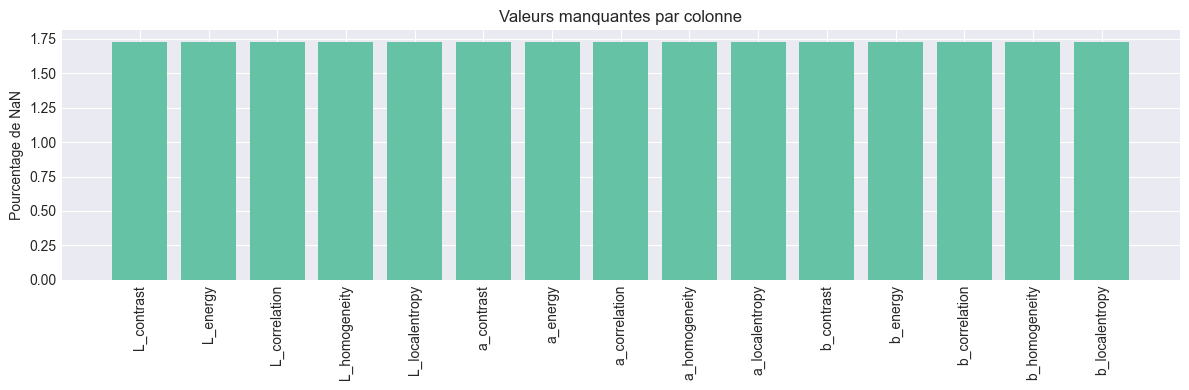

In [3]:

missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing_count.index,
    'Nb_NaN': missing_count.values,
    'Pourcentage': missing_percent.values
})
missing_df = missing_df[missing_df['Nb_NaN'] > 0].sort_values('Pourcentage', ascending=False)

print("VALEURS MANQUANTES :")
if len(missing_df) > 0:
    print(missing_df)
    
    # Visualisation
    plt.figure(figsize=(12, 4))
    plt.bar(missing_df['Colonne'], missing_df['Pourcentage'])
    plt.xticks(rotation=90)
    plt.ylabel('Pourcentage de NaN')
    plt.title('Valeurs manquantes par colonne')
    plt.tight_layout()
    plt.show()
else:
    print(" Aucune valeur manquante trouvée !")

In [4]:
df_raw[df_raw['L_contrast'].isna()]

,Code,Peau,Age,IMC,Co,Se,TE,pH,L_front,a_front,b_front,C_front,h_front,ITA_front,IWA_front,Front_aire_porphy,Front_int_porphy,Front_Lightness,Front_Spec_Bright,Front_Global_Bright,Front_aire_pacnes,Front_int_pacnes,Front_nb_pts_pacnes,L_contrast,L_energy,L_correlation,L_homogeneity,L_localentropy,a_contrast,a_energy,a_correlation,a_homogeneity,a_localentropy,b_contrast,b_energy,b_correlation,b_homogeneity,b_localentropy,274_0_0657,283_0_1145,301_0_1183,301_0_1742,301_0_2078,311_0_1361,329_0_1371,330_0_1371,355_0_1760,456_0_2205,469_0_2218,470_02271,484_0_2264,484_0_2423,498_0_2431,498_0_2498,498_0_2541,521_0_1274,633_0_3740,638_0_3681,334_13_828,335_19_357,507_44_556,557_34_1693,602_49_1698,638_61_427,691_59_1706,849_68_1637,850_71_1637,878_71_1622,1190_11_268,1199_244,1273_84_262,1288_18_259
27,V31,3,19,20.800,66.333,181.000,8.350,4.300,56.526,15.699,22.669,27.574,55.296,16.061,63.996,0.016,0.597,246,0.019,0.228,0.007,0.315,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.668,2.502,2.241,2.425,2.383,2.559,2.142,2.399,2.472,1.484,1.906,1.763,2.360,1.247,1.931,1.602,0.592,1.843,1.783,1.670,2.279,2.358,2.518,0.942,1.085,3.731,1.312,1.224,1.624,1.312,2.438,2.644,2.263,2.149


- une seule ligne qui a des colonnes avec NaN
- --------------------------------------------------
- Si on avait un grand dataset on prend drectement la decision de suprimer la ligne avec les données manquante puisque il s'agit d'une seul ligne
- Dans notre cas on garder la ligne et faire une imputation

## **Étape 3 : Prétraitement complet**

In [5]:
# ============================================
# ÉTAPE 3 : PRÉTRAITEMENT
# ============================================

# 3.1 Séparation features / target
X_raw = df_raw.drop(['Code', 'Peau'], axis=1)
y_raw = df_raw['Peau']
codes = df_raw['Code']

print("- SÉPARATION DES DONNÉES : ")
print(f"Features     : {X_raw.shape}")
print(f"Target       : {y_raw.shape}")
print(f"Types de peau: {sorted(y_raw.unique())}")

# 3.2 Imputation KNN
print("\n- IMPUTATION KNN  :") # Robuste
knn_imputer = KNNImputer(n_neighbors=5)
X_imputed = knn_imputer.fit_transform(X_raw)
X_imputed_df = pd.DataFrame(X_imputed, columns=X_raw.columns)

print(f"NaN après imputation: {X_imputed_df.isnull().sum().sum()}")

# 3.3 Standardisation
print("\n- STANDARDISATION   : ")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df)
X_scaled = pd.DataFrame(X_scaled, columns=X_imputed_df.columns)

print(f" Moyennes après standardisation     : {X_scaled.mean().round(2).unique()}")
print(f" Écarts-types après standardisation : {X_scaled.std().round(2).unique()}")


- SÉPARATION DES DONNÉES : 
Features     : (58, 70)
Target       : (58,)
Types de peau: [np.int64(1), np.int64(2), np.int64(3)]

- IMPUTATION KNN  :
NaN après imputation: 0

- STANDARDISATION   : 
 Moyennes après standardisation     : [0.]
 Écarts-types après standardisation : [1.01]


## **Étape 4 : ACP pour visualisation**

- ANALYSE DE LA VARIANCE :
 Variance PC1 ................. : 29.5%
 Variance PC2 ................. : 12.2%
 Variance cumulée 2PC ......... : 41.7%
 Nombre de composantes pour 80% : 11


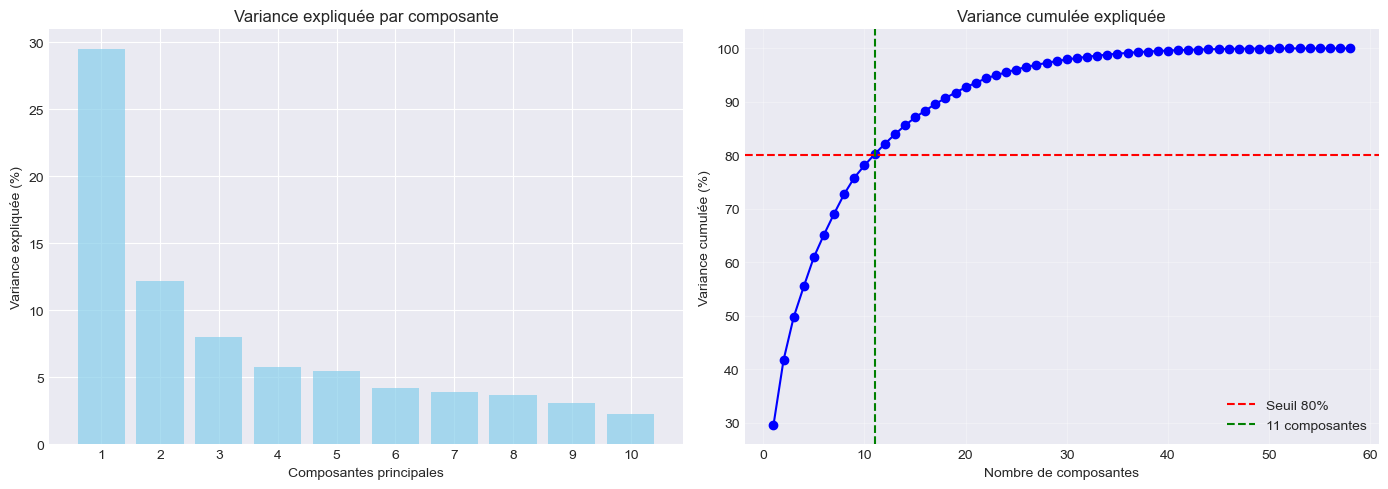

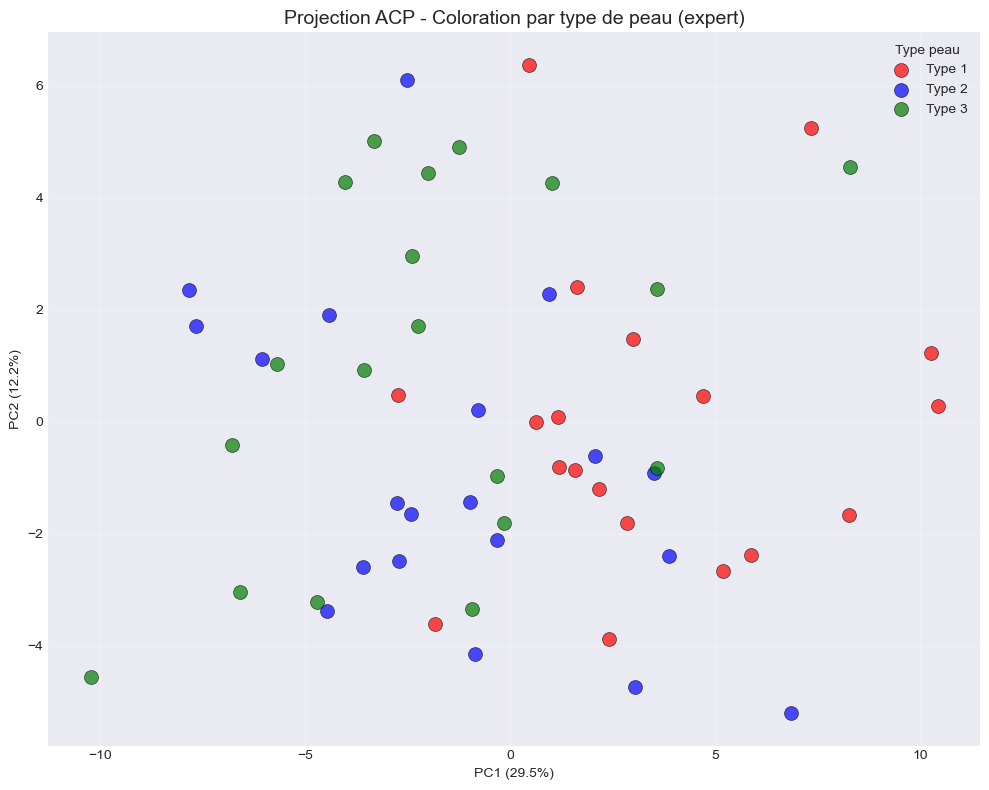

In [ ]:
# 4.1 Application de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4.2 Variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1

print("- ANALYSE DE LA VARIANCE :")
print(f" Variance PC1 ................. : {explained_variance[0]*100:.1f}%")
print(f" Variance PC2 ................. : {explained_variance[1]*100:.1f}%")
print(f" Variance cumulée 2PC ......... : {(explained_variance[0]+explained_variance[1])*100:.1f}%")
print(f" Nombre de composantes pour 80% : {n_components_80}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance individuelle
axes[0].bar(range(1, 11), explained_variance[:10] * 100, alpha=0.7, color='skyblue')
axes[0].set_xlabel('Composantes principales')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Variance expliquée par composante')
axes[0].set_xticks(range(1, 11))

# Variance cumulée
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'bo-')
axes[1].axhline(y=80, color='r', linestyle='--', label='Seuil 80%')
axes[1].axvline(x=n_components_80, color='g', linestyle='--', label=f'{n_components_80} composantes')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée expliquée')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.3 DataFrame pour visualisation 2D
X_pca_2d = X_pca[:, :2]
df_pca = pd.DataFrame({
    'Code': codes.values,
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Peau': y_raw.values
})

# Visualisation avec labels experts
plt.figure(figsize=(10, 8))
colors = {1: 'red', 2: 'blue', 3: 'green'}
for peau in [1, 2, 3]:
    mask = df_pca['Peau'] == peau
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
                c=colors[peau], label=f'Type {peau}', s=100, alpha=0.7, 
                edgecolors='black', linewidth=0.5)

plt.title('Projection ACP - Coloration par type de peau (expert)', fontsize=14)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='Type peau')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Étape 5 : - Sélection des variables discriminantes**
  **- Choix de methode : (ANOVA)**

- SÉLECTION DES VARIABLES LES PLUS DISCRIMINANTES :
  Méthode: ANOVA (Analyse de Variance)

- TOP 20 VARIABLES LES PLUS DISCRIMINANTES (ANOVA):
----------------------------------------------------------------------
 rang            variable  f_score  p_value
    1 Front_nb_pts_pacnes    9.489    0.000
    2          638_61_427    7.110    0.002
    3          311_0_1361    6.552    0.003
    4          283_0_1145    6.296    0.003
    5          301_0_1183    6.016    0.004
    6         691_59_1706    5.868    0.005
    7          507_44_556    5.549    0.006
    8         1288_18_259    5.425    0.007
    9         1273_84_262    5.408    0.007
   10          638_0_3681    5.354    0.008
   11         1190_11_268    5.279    0.008
   12     Front_Lightness    5.210    0.008
   13          484_0_2264    5.200    0.009
   14          301_0_1742    5.047    0.010
   15          456_0_2205    4.966    0.010
   16 Front_Global_Bright    4.961    0.010
   17          484_0_2423    4.868   

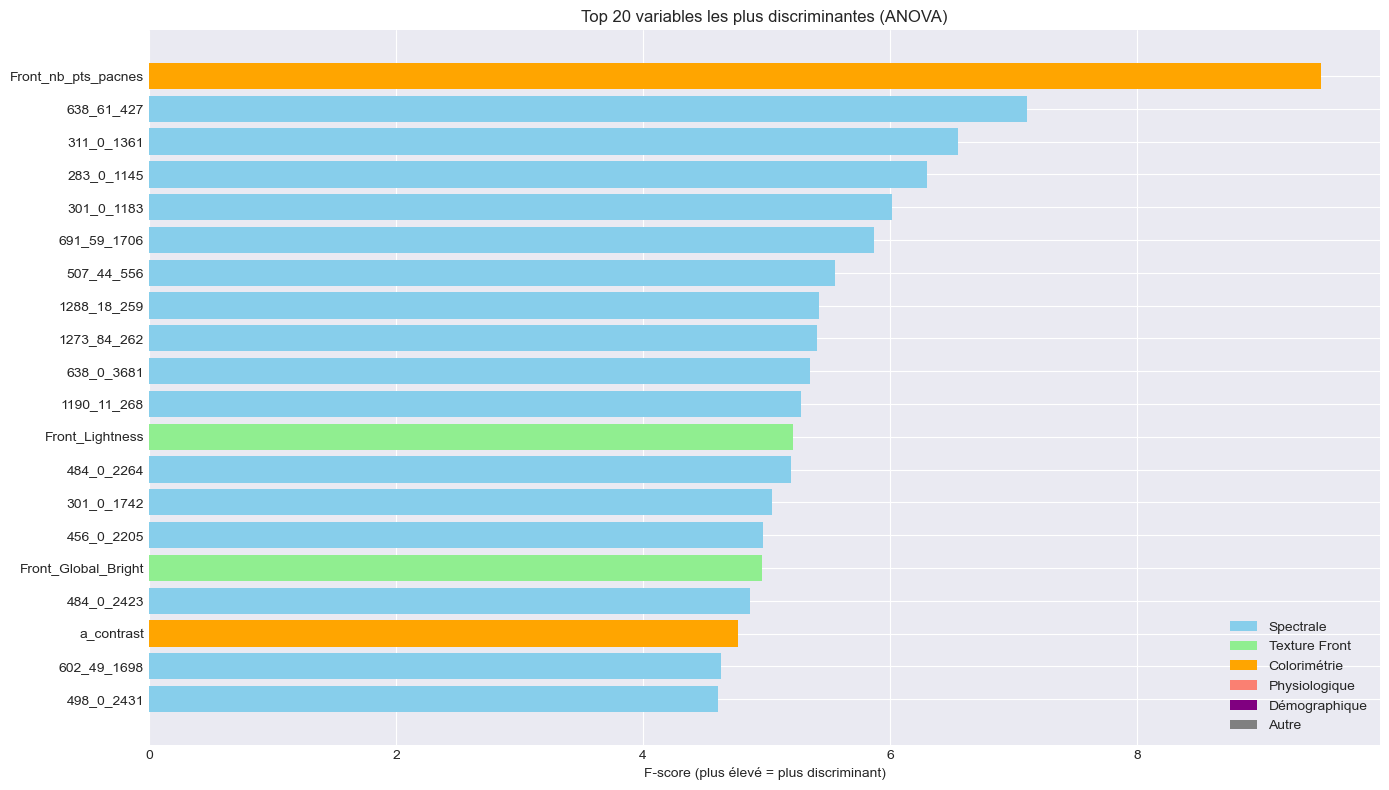

In [ ]:
# ============================================
# ÉTAPE 5 : SÉLECTION DES VARIABLES DISCRIMINANTES AVEC ANOVA
# ============================================

print("- SÉLECTION DES VARIABLES LES PLUS DISCRIMINANTES :")
print("  Méthode: ANOVA (Analyse de Variance)\n")

# 5.1 Calcul des scores F
f_scores, p_values = f_classif(X_scaled, y_raw)

# 5.2 Création du DataFrame des résultats
anova_results = pd.DataFrame({
    'variable': X_scaled.columns,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False).reset_index(drop=True)

# 5.3 Ajout du rang et du cumul
anova_results['rang'] = anova_results.index + 1
anova_results['cumul_f_score'] = anova_results['f_score'].cumsum() / anova_results['f_score'].sum() * 100

print("- TOP 20 VARIABLES LES PLUS DISCRIMINANTES (ANOVA):")
print("-"*70)
print(anova_results[['rang', 'variable', 'f_score', 'p_value']].head(20).to_string(index=False))

# 5.4 Identification des catégories de variables
def categoriser_variable(var_name):
    if any(x in var_name for x in ['Age', 'IMC']):
        return 'Démographique'
    elif any(x in var_name for x in ['Co', 'Se', 'TE', 'pH']):
        return 'Physiologique'
    elif any(x in var_name for x in ['L_', 'a_', 'b_', 'C_', 'h_', 'ITA', 'IWA']):
        return 'Colorimétrie'
    elif 'Front' in var_name:
        return 'Texture Front'
    elif var_name[0].isdigit():  # Variables spectrales (commencent par un nombre)
        return 'Spectrale'
    else:
        return 'Autre'

anova_results['categorie'] = anova_results['variable'].apply(categoriser_variable)

# 5.5 Statistiques par catégorie
print("\n- STATISTIQUES PAR CATÉGORIE:")
print("="*50)
categorie_stats = anova_results.groupby('categorie').agg({
    'f_score': ['count', 'mean', 'max'],
    'rang': 'min'
}).round(2)
categorie_stats.columns = ['Nb_vars', 'F_score_moyen', 'F_score_max', 'Meilleur_rang']
categorie_stats = categorie_stats.sort_values('F_score_moyen', ascending=False)
print(categorie_stats)

# 5.6 Visualisation des top variables
plt.figure(figsize=(14, 8))
top20 = anova_results.head(20)
colors_cat = {'Spectrale': 'skyblue', 'Texture Front': 'lightgreen', 
              'Colorimétrie': 'orange', 'Physiologique': 'salmon', 
              'Démographique': 'purple', 'Autre': 'gray'}
bar_colors = [colors_cat[cat] for cat in top20['categorie']]

bars = plt.barh(range(len(top20)), top20['f_score'].values, color=bar_colors)
plt.yticks(range(len(top20)), top20['variable'].values)
plt.xlabel('F-score (plus élevé = plus discriminant)')
plt.title('Top 20 variables les plus discriminantes (ANOVA)')
plt.gca().invert_yaxis()

# Ajouter une légende pour les catégories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat) for cat, color in colors_cat.items()]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## **Étape 5-1 : Analyse détaillée des variables discriminantes**

In [ ]:

# 5-1.1 Extraction des top variables par catégorie
print("- TOP VARIABLES PAR CATÉGORIE :")
print("-"*60)

categories_uniques = anova_results['categorie'].unique()
top_vars_par_categorie = {}

for cat in categories_uniques:
    cat_vars = anova_results[anova_results['categorie'] == cat].head(3)
    top_vars_par_categorie[cat] = cat_vars['variable'].tolist()
    
    print(f"\n {cat}:")
    for _, row in cat_vars.iterrows():
        print(f"   - {row['variable']:30} (F={row['f_score']:.2f}, rang={int(row['rang'])})")

# 5-1.2 Sélection automatique des variables clés pour l'interprétation
# On prend le top 15 toutes catégories confondues
n_vars_interpretation = 15
key_vars_anova = anova_results.head(n_vars_interpretation)['variable'].tolist()

print(f"\n- VARIABLES CLÉS POUR L'INTERPRÉTATION (top {n_vars_interpretation}) :")
for i, var in enumerate(key_vars_anova, 1):
    f_score = anova_results[anova_results['variable'] == var]['f_score'].values[0]
    cat = anova_results[anova_results['variable'] == var]['categorie'].values[0]
    print(f"{i:2d}. {var:35} (F={f_score:.2f}, {cat})")

# 5-1.3 Vérification de la position des variables manuelles
manual_vars = ['Age', 'IMC', 'Co', 'Se', 'TE', 'pH']
print("\n- POSITION DES VARIABLES MANUELLES DANS LE CLASSEMENT :")
print("-" * 50)

for var in manual_vars:
    if var in anova_results['variable'].values:
        row = anova_results[anova_results['variable'] == var].iloc[0]
        print(f"  {var:10} : rang {int(row['rang']):3d}/{len(anova_results)} (F={row['f_score']:.2f})")
    else:
        # Chercher des variantes (avec underscore)
        var_alt = var + '_'
        matches = [v for v in anova_results['variable'] if var_alt in v]
        if matches:
            row = anova_results[anova_results['variable'] == matches[0]].iloc[0]
            print(f"  {var:10} → {matches[0]:20} rang {int(row['rang']):3d} (F={row['f_score']:.2f})")
        else:
            print(f"  {var:10} → non trouvée")

- TOP VARIABLES PAR CATÉGORIE :
------------------------------------------------------------

 Colorimétrie:
   - Front_nb_pts_pacnes            (F=9.49, rang=1)
   - a_contrast                     (F=4.77, rang=18)
   - a_front                        (F=4.03, rang=28)

 Spectrale:
   - 638_61_427                     (F=7.11, rang=2)
   - 311_0_1361                     (F=6.55, rang=3)
   - 283_0_1145                     (F=6.30, rang=4)

 Texture Front:
   - Front_Lightness                (F=5.21, rang=12)
   - Front_Global_Bright            (F=4.96, rang=16)
   - Front_aire_porphy              (F=3.77, rang=32)

 Physiologique:
   - Se                             (F=2.62, rang=51)
   - TE                             (F=1.96, rang=57)
   - Co                             (F=0.09, rang=68)

 Démographique:
   - IMC                            (F=0.84, rang=63)
   - Age                            (F=0.15, rang=66)

- VARIABLES CLÉS POUR L'INTERPRÉTATION (top 15) :
 1. Front_nb_pts_pacnes 

## **Étape 6 : K-means avec recherche du k optimal**

- RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS (K-MEANS) :
  k=2: silhouette=0.154, inertie=3259
  k=3: silhouette=0.107, inertie=2992
  k=4: silhouette=0.096, inertie=2746
  k=5: silhouette=0.094, inertie=2550
  k=6: silhouette=0.091, inertie=2406
  k=7: silhouette=0.075, inertie=2348
  k=8: silhouette=0.070, inertie=2289
  k=9: silhouette=0.068, inertie=2148
  k=10: silhouette=0.053, inertie=2076


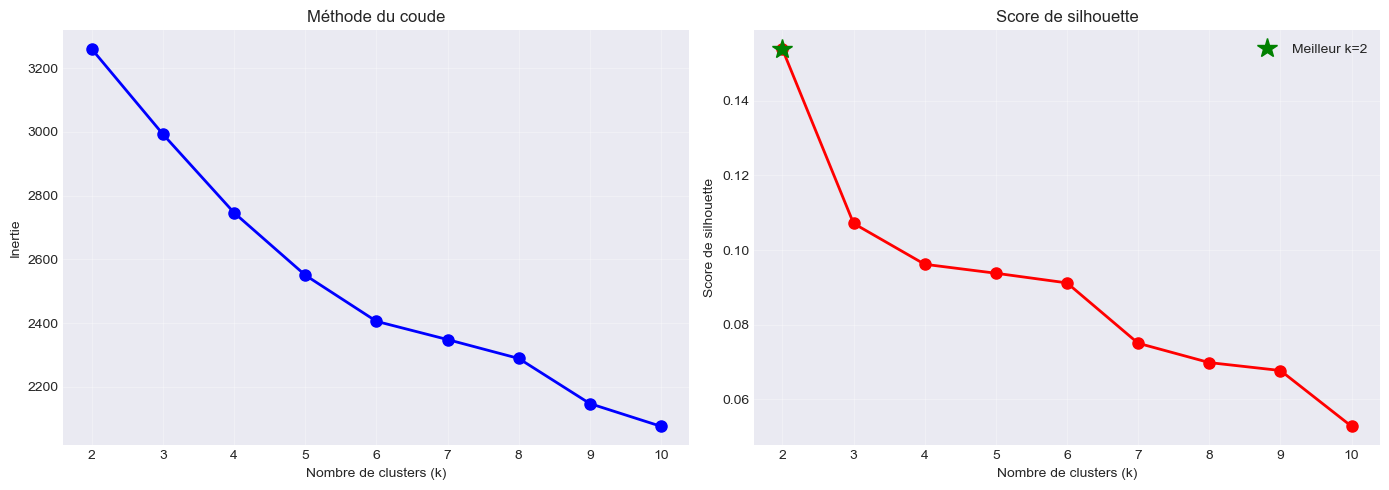


- Meilleur k selon silhouette: 2 (score=0.154)

- Distribution des clusters:
  Cluster 0: 31 femmes (53.4%)
  Cluster 1: 27 femmes (46.6%)


In [ ]:

print("- RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS (K-MEANS) :")

# 6.1 Test de différents k
K_range = range(2, 11)
inertias = []
silhouette_scores = []
kmeans_models = {}

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    kmeans_models[k] = {'model': kmeans, 'labels': labels}
    
    print(f"  k={k}: silhouette={silhouette_scores[-1]:.3f}, inertie={inertias[-1]:.0f}")

# 6.2 Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Méthode du coude
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')
axes[0].grid(True, alpha=0.3)

# Score de silhouette
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Score de silhouette')
axes[1].grid(True, alpha=0.3)

# Meilleur k
best_k = K_range[np.argmax(silhouette_scores)]
axes[1].plot(best_k, max(silhouette_scores), 'g*', markersize=15, label=f'Meilleur k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n- Meilleur k selon silhouette: {best_k} (score={max(silhouette_scores):.3f})")

# 6.3 Application avec le meilleur k
best_kmeans = kmeans_models[best_k]['model']
kmeans_labels = kmeans_models[best_k]['labels']

# Distribution
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\n- Distribution des clusters:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} femmes ({count/len(kmeans_labels)*100:.1f}%)")

## **Étape 7 : Interprétation des clusters avec les variables discriminantes**

- INTERPRÉTATION DES CLUSTERS AVEC VARIABLES DISCRIMINANTES : 
- PROFIL DES CLUSTERS SUR LES 15 VARIABLES LES PLUS DISCRIMINANTES:
--------------------------------------------------------------------------------

- Cluster 0 (31 femmes):
  + Front_nb_pts_pacnes                 =    0.001 (vs moy   0.001, diff=+0.00, +23.5%)
  - 638_61_427                          =    3.282 (vs moy   3.527, diff=-0.25, -6.9%)
  - 311_0_1361                          =    2.028 (vs moy   2.337, diff=-0.31, -13.2%)
  - 283_0_1145                          =    2.021 (vs moy   2.418, diff=-0.40, -16.4%)
  - 301_0_1183                          =    2.278 (vs moy   2.543, diff=-0.26, -10.4%)
  - 691_59_1706                         =    1.856 (vs moy   2.072, diff=-0.22, -10.4%)
  - 507_44_556                          =    2.535 (vs moy   2.700, diff=-0.16, -6.1%)
  - 1288_18_259                         =    2.207 (vs moy   2.411, diff=-0.20, -8.5%)
  - 1273_84_262                         =    2.318 (vs moy   

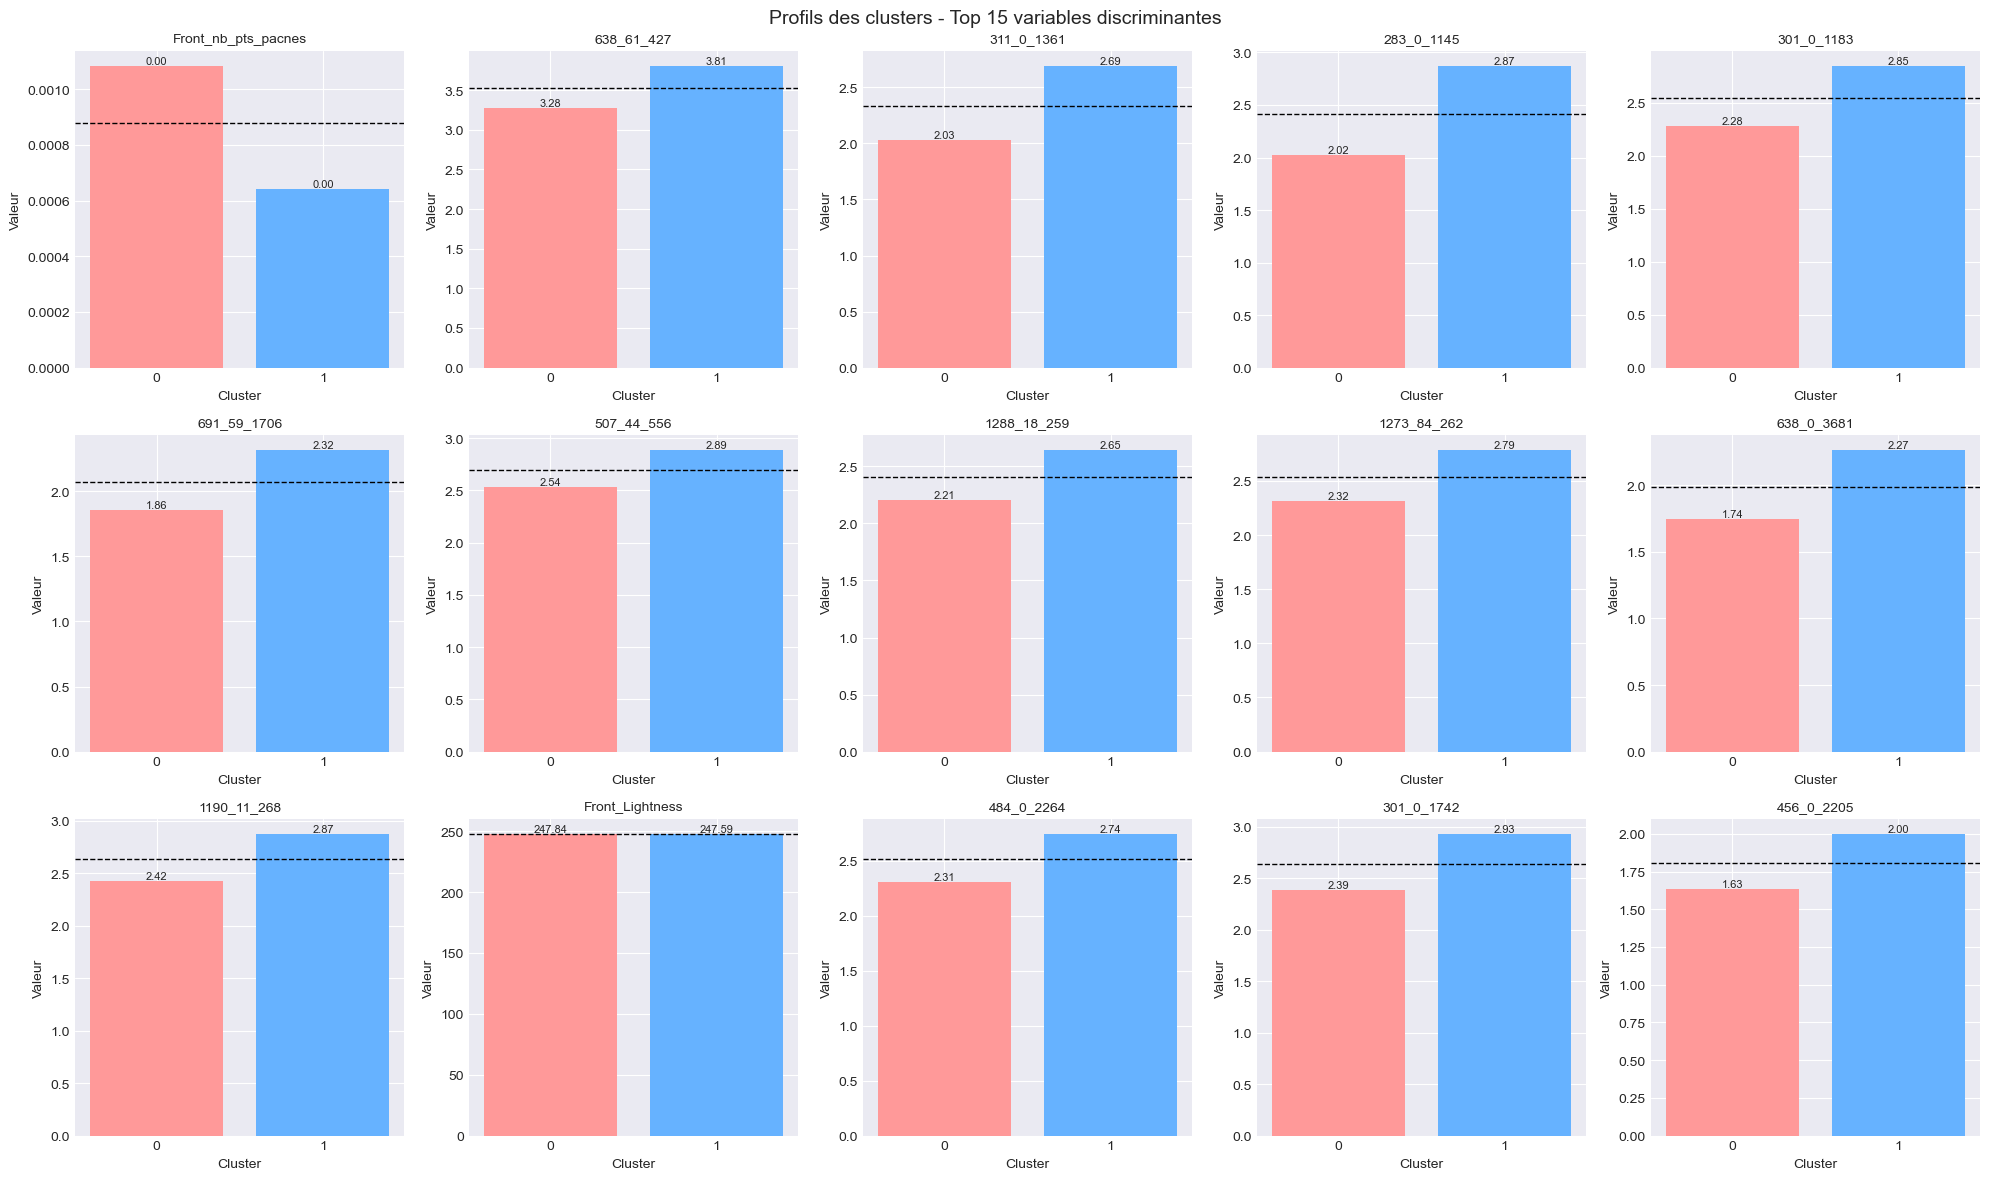

In [ ]:

print("- INTERPRÉTATION DES CLUSTERS AVEC VARIABLES DISCRIMINANTES : ")

# 7.1 Centres des clusters en valeurs originales
centers_original = scaler.inverse_transform(best_kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=X_scaled.columns)
centers_df.index = [f'Cluster {i}' for i in range(best_k)]

# 7.2 Profil sur les variables clés (top 15 ANOVA)
print(f"- PROFIL DES CLUSTERS SUR LES {len(key_vars_anova)} VARIABLES LES PLUS DISCRIMINANTES:")
print("-"*80)

for cluster in range(best_k):
    print(f"\n- Cluster {cluster} ({counts[cluster]} femmes):")
    
    for var in key_vars_anova[:10]:  # Top 10 pour lisibilité
        val = centers_df.loc[f'Cluster {cluster}', var]
        global_mean = X_imputed_df[var].mean()
        diff = val - global_mean
        trend = "+" if diff > 0 else "-"
        
        # Intensité de la différence
        diff_pct = (diff / global_mean) * 100 if global_mean != 0 else 0
        
        print(f"  {trend} {var:35} = {val:8.3f} (vs moy {global_mean:7.3f}, diff={diff:+.2f}, {diff_pct:+.1f}%)")

# 7.3 Visualisation des profils
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for i, var in enumerate(key_vars_anova[:15]):
    ax = axes[i]
    values = [centers_df.loc[f'Cluster {c}', var] for c in range(best_k)]
    
    # Ajouter la moyenne globale
    global_mean = X_imputed_df[var].mean()
    
    bars = ax.bar(range(best_k), values, color=['#FF9999', '#66B2FF', '#99FF99'][:best_k])
    ax.axhline(y=global_mean, color='black', linestyle='--', linewidth=1, label='Moyenne globale')
    
    # Tronquer les noms trop longs
    short_name = var if len(var) <= 20 else var[:17] + '...'
    ax.set_title(f'{short_name}', fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Valeur')
    ax.set_xticks(range(best_k))
    
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Profils des clusters - Top 15 variables discriminantes', fontsize=14)
plt.tight_layout()
plt.show()

# **Étape 8 : Comparaison avec l'expert**

- TABLE DE CONTINGENCE K-MEANS vs EXPERT  :
Type peau expert   1   2   3
Cluster K-means             
0                  2  14  15
1                 17   6   4

- Indice de Rand ajusté (ARI): 0.222
- Faible accord avec l'expert car Indice < 0.3

- ANALYSE DÉTAILLÉE PAR CLUSTER:
--------------------------------------------------

- Cluster 0 (31 femmes):
  -- Type majoritaire: 3 (15 femmes, 48.4%)
  -----Type 1:  2 (  6.5%)
  -----Type 2: 14 ( 45.2%)
  -----Type 3: 15 ( 48.4%)

- Cluster 1 (27 femmes):
  -- Type majoritaire: 1 (17 femmes, 63.0%)
  -----Type 1: 17 ( 63.0%)
  -----Type 2:  6 ( 22.2%)
  -----Type 3:  4 ( 14.8%)


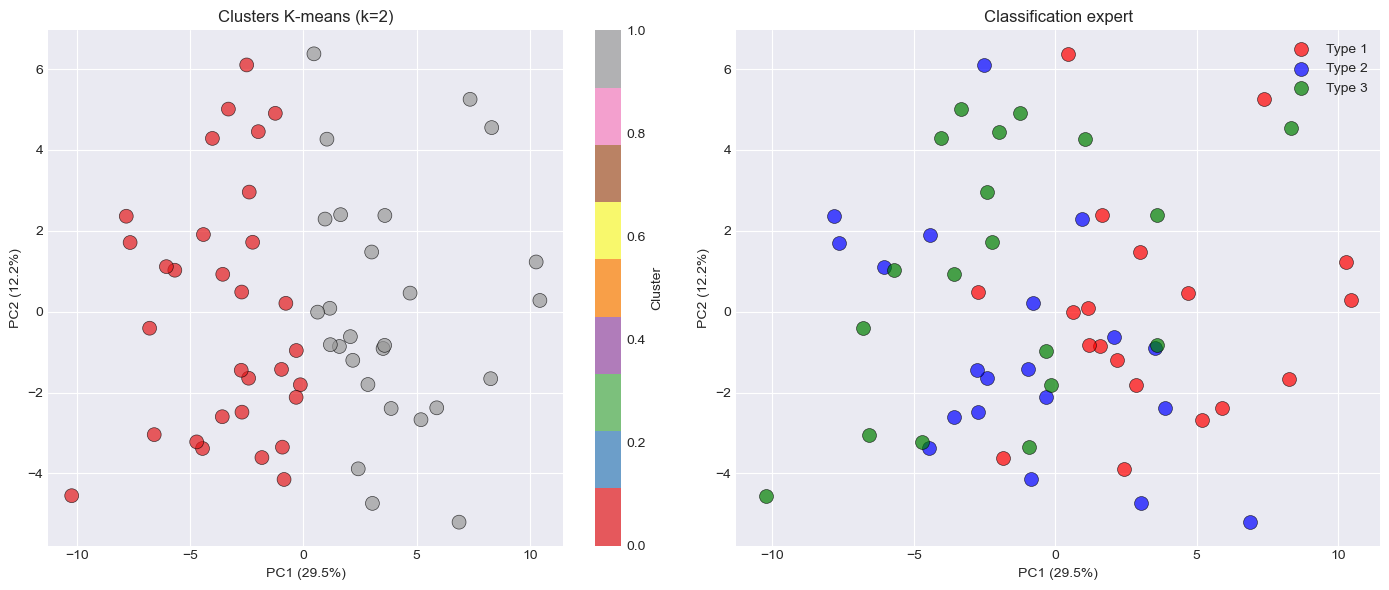

In [ ]:

# 8.1 Table de contingence
confusion_matrix = pd.crosstab(
    kmeans_labels, 
    y_raw,
    rownames=['Cluster K-means'], 
    colnames=['Type peau expert']
)

print("- TABLE DE CONTINGENCE K-MEANS vs EXPERT  :")
print(confusion_matrix)

# 8.2 Indice de Rand ajusté
ari_kmeans = adjusted_rand_score(y_raw, kmeans_labels)
print(f"\n- Indice de Rand ajusté (ARI): {ari_kmeans:.3f}")

# Interprétation
if ari_kmeans > 0.5:
    print("- Bon accord avec l'expert car Indice > 0.5")
elif ari_kmeans > 0.3:
    print("- Accord modéré avec l'expert car Indice < 0.3 et < 0.5")
else:
    print("- Faible accord avec l'expert car Indice < 0.3")

# 8.3 Analyse détaillée de la correspondance
print("\n- ANALYSE DÉTAILLÉE PAR CLUSTER:")
print("-" * 50)

for cluster in range(best_k):
    cluster_types = y_raw[kmeans_labels == cluster].value_counts()
    total = sum(kmeans_labels == cluster)
    
    print(f"\n- Cluster {cluster} ({total} femmes):")
    
    # Type majoritaire
    if len(cluster_types) > 0:
        major_type = cluster_types.index[0]
        major_count = cluster_types.values[0]
        major_pct = major_count / total * 100
        print(f"  -- Type majoritaire: {major_type} ({major_count} femmes, {major_pct:.1f}%)")
    
    # Composition détaillée
    for type_peau in [1, 2, 3]:
        if type_peau in cluster_types.index:
            count = cluster_types[type_peau]
            pct = count / total * 100
            print(f"  -----Type {type_peau}: {count:2d} ({pct:5.1f}%)")
        else:
            print(f"  -----Type {type_peau}:  0 (  0%)")

# 8.4 Visualisation
df_pca['Cluster_KMeans'] = kmeans_labels

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], 
                      c=df_pca['Cluster_KMeans'], cmap='Set1', s=100, alpha=0.7,
                      edgecolors='black', linewidth=0.5)
plt.title(f'Clusters K-means (k={best_k})')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
for peau in [1, 2, 3]:
    mask = df_pca['Peau'] == peau
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
                c=colors[peau], label=f'Type {peau}', s=100, alpha=0.7,
                edgecolors='black', linewidth=0.5)
plt.title('Classification expert')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend()

plt.tight_layout()
plt.show()

## **Étape 9 : CAH (Classification Ascendante Hiérarchique)**

- CLASSIFICATION ASCENDANTE HIÉRARCHIQUE ===


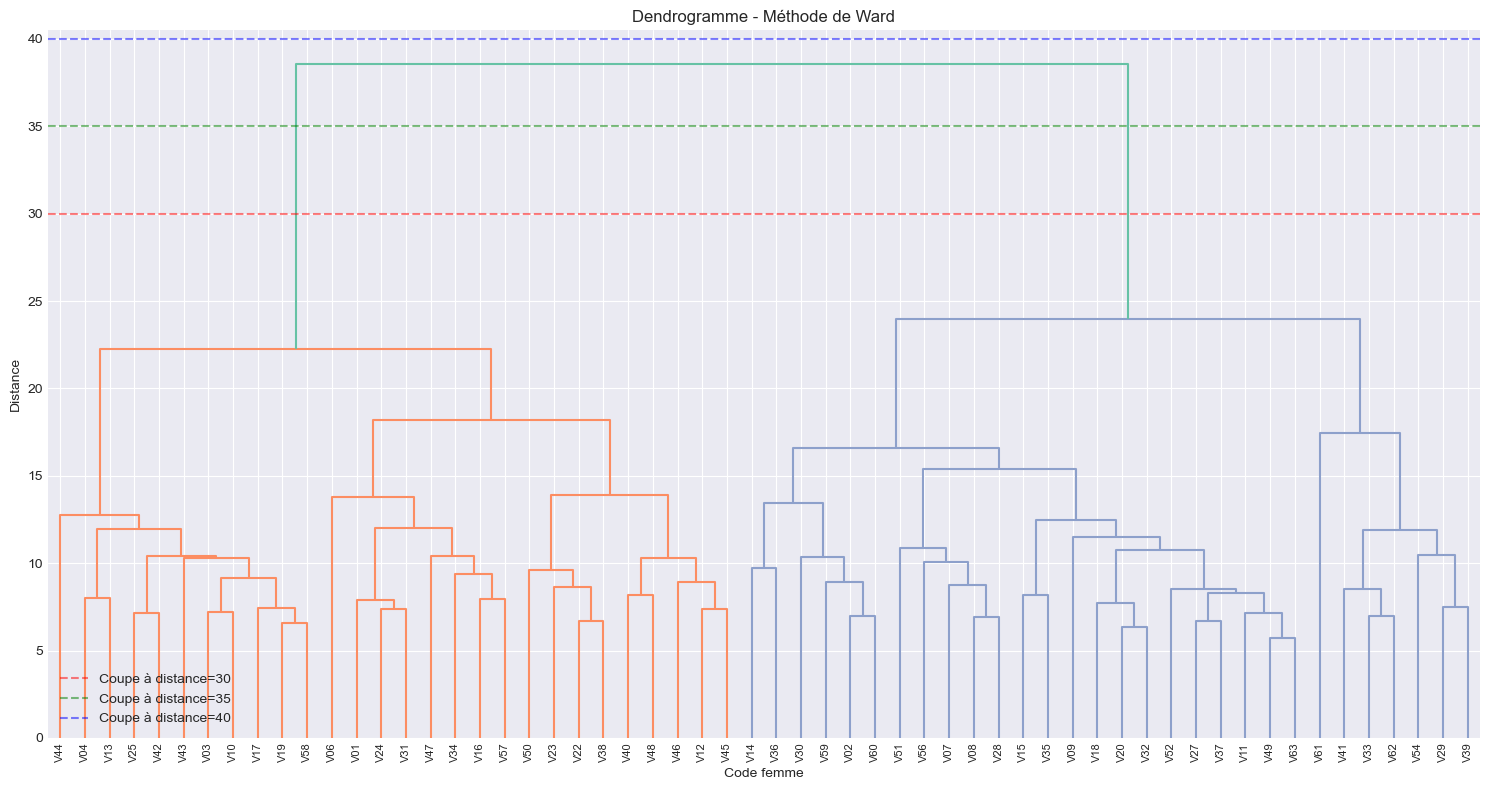


- Distribution des clusters CAH:
  Cluster 1: 28 femmes (48.3%)
  Cluster 2: 30 femmes (51.7%)

- TABLE DE CONTINGENCE CAH vs EXPERT :
Type peau expert   1   2   3
Cluster CAH                 
1                  3  11  14
2                 16   9   5

- ARI (CAH): 0.130


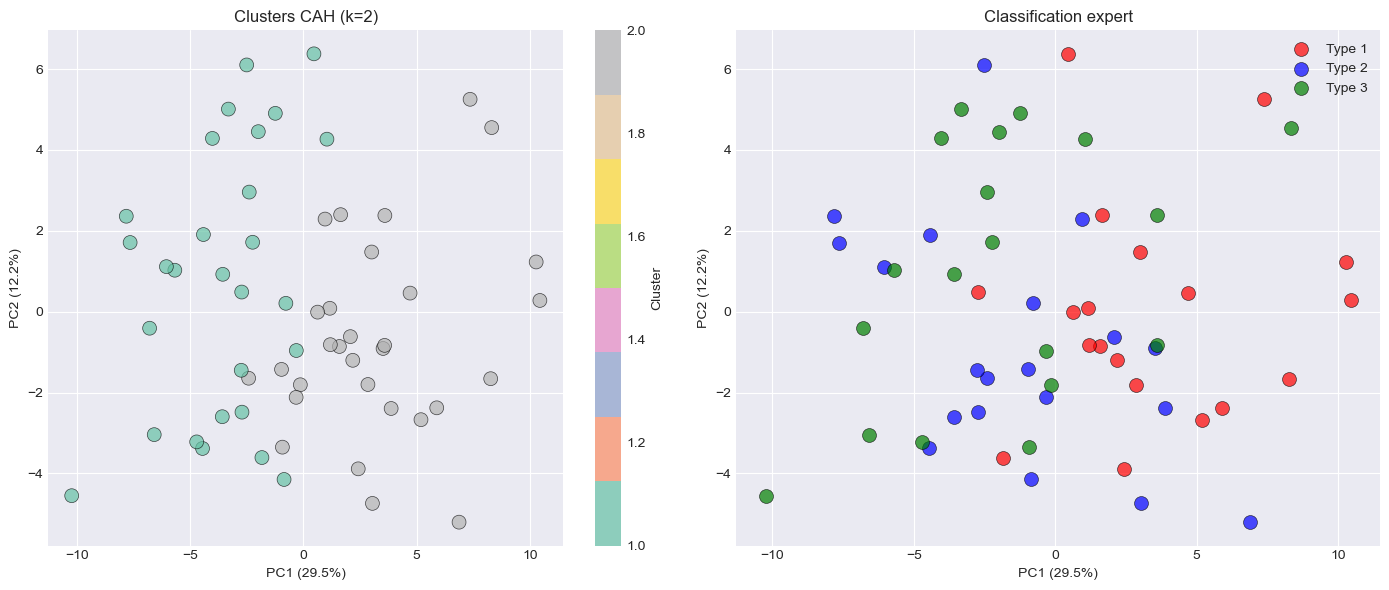

In [ ]:

print("- CLASSIFICATION ASCENDANTE HIÉRARCHIQUE ===")

# 9.1 Calcul de la matrice de liaison (méthode de Ward)
Z = linkage(X_scaled, method='ward')

# 9.2 Dendrogramme
plt.figure(figsize=(15, 8))
dendrogram(Z, labels=codes.values, leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogramme - Méthode de Ward')
plt.xlabel('Code femme')
plt.ylabel('Distance')
plt.axhline(y=30, color='r', linestyle='--', alpha=0.5, label='Coupe à distance=30')
plt.axhline(y=35, color='g', linestyle='--', alpha=0.5, label='Coupe à distance=35')
plt.axhline(y=40, color='b', linestyle='--', alpha=0.5, label='Coupe à distance=40')
plt.legend()
plt.tight_layout()
plt.show()

# 9.3 Détermination du nombre de clusters
# On prend le même nombre que le meilleur k de K-means pour comparaison
hier_labels = fcluster(Z, best_k, criterion='maxclust')

# Distribution
unique_h, counts_h = np.unique(hier_labels, return_counts=True)
print("\n- Distribution des clusters CAH:")
for cluster, count in zip(unique_h, counts_h):
    print(f"  Cluster {cluster}: {count} femmes ({count/len(hier_labels)*100:.1f}%)")

# 9.4 Table de contingence CAH vs Expert
confusion_hier = pd.crosstab(
    hier_labels, 
    y_raw,
    rownames=['Cluster CAH'], 
    colnames=['Type peau expert']
)

print("\n- TABLE DE CONTINGENCE CAH vs EXPERT :")
print(confusion_hier)

# 9.5 Indice de Rand ajusté
ari_hier = adjusted_rand_score(y_raw, hier_labels)
print(f"\n- ARI (CAH): {ari_hier:.3f}")

# 9.6 Visualisation
df_pca['Cluster_CAH'] = hier_labels

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], 
                      c=df_pca['Cluster_CAH'], cmap='Set2', s=100, alpha=0.7,
                      edgecolors='black', linewidth=0.5)
plt.title(f'Clusters CAH (k={best_k})')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
for peau in [1, 2, 3]:
    mask = df_pca['Peau'] == peau
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
                c=colors[peau], label=f'Type {peau}', s=100, alpha=0.7,
                edgecolors='black', linewidth=0.5)
plt.title('Classification expert')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend()

plt.tight_layout()
plt.show()

## **Étape 10 : DBSCAN - Détection automatique du nombre de clusters**

- DBSCAN : CLUSTERING BASÉ SUR LA DENSITÉ :


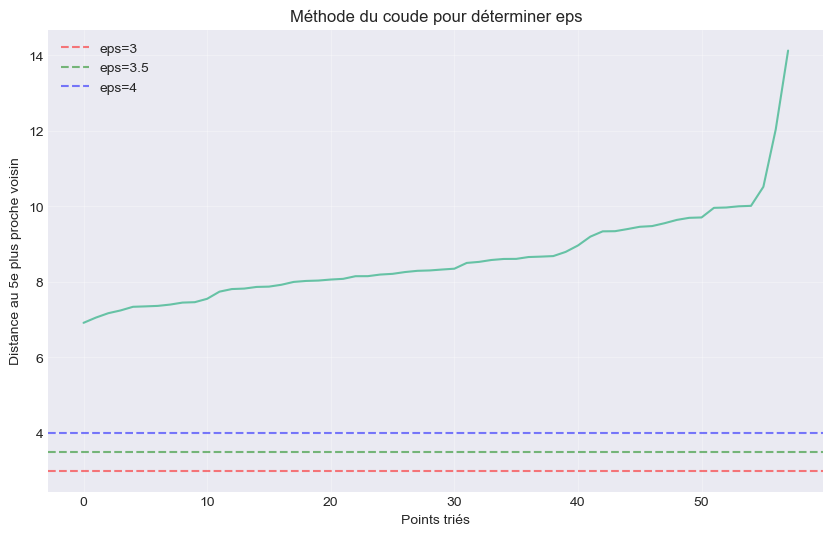

- TEST DES PARAMÈTRES DBSCAN:
------------------------------------------------------------
eps    min_samples  clusters   bruit      silhouette
------------------------------------------------------------
2.5    3            0          58         (100%) -         
2.5    4            0          58         (100%) -         
2.5    5            0          58         (100%) -         
3.0    3            0          58         (100%) -         
3.0    4            0          58         (100%) -         
3.0    5            0          58         (100%) -         
3.5    3            0          58         (100%) -         
3.5    4            0          58         (100%) -         
3.5    5            0          58         (100%) -         
4.0    3            0          58         (100%) -         
4.0    4            0          58         (100%) -         
4.0    5            0          58         (100%) -         
4.5    3            0          58         (100%) -         
4.5    4       

In [ ]:
# ============================================
# ÉTAPE 10 : DBSCAN (DENSITY-BASED CLUSTERING)
# ============================================

print("- DBSCAN : CLUSTERING BASÉ SUR LA DENSITÉ :")

# 10.1 Détermination du paramètre eps (méthode du coude)
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, 4])  # 5e plus proche voisin

plt.figure(figsize=(10, 6))
plt.plot(k_dist)
plt.xlabel('Points triés')
plt.ylabel('Distance au 5e plus proche voisin')
plt.title('Méthode du coude pour déterminer eps')
plt.grid(True, alpha=0.3)
plt.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='eps=3')
plt.axhline(y=3.5, color='g', linestyle='--', alpha=0.5, label='eps=3.5')
plt.axhline(y=4, color='b', linestyle='--', alpha=0.5, label='eps=4')
plt.legend()
plt.show()

# 10.2 Test des paramètres
eps_values = [2.5, 3, 3.5, 4, 4.5]
min_samples_values = [3, 4, 5]

print("- TEST DES PARAMÈTRES DBSCAN:")
print("-" * 60)
print(f"{'eps':<6} {'min_samples':<12} {'clusters':<10} {'bruit':<10} {'silhouette':<10}")
print("-" * 60)

best_score = -1
best_params = None
best_dbscan_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = n_noise / len(labels) * 100
        
        # Calcul du silhouette (si possible)
        if n_clusters >= 2 and n_noise < len(labels) * 0.2:  # Moins de 20% de bruit
            mask = labels != -1
            if sum(mask) >= n_clusters * 2:
                sil = silhouette_score(X_scaled[mask], labels[mask])
                print(f"{eps:<6.1f} {min_samples:<12d} {n_clusters:<10d} {n_noise:<10d} ({noise_pct:.0f}%) {sil:<10.3f}")
                
                if sil > best_score:
                    best_score = sil
                    best_params = (eps, min_samples)
                    best_dbscan_labels = labels
        else:
            print(f"{eps:<6.1f} {min_samples:<12d} {n_clusters:<10d} {n_noise:<10d} ({noise_pct:.0f}%) {'-':<10}")

# 10.3 Résultats finaux
print("\n" + "="*60)
if best_params:
    print(f"- Meilleurs paramètres: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"   Score silhouette: {best_score:.3f}")
    
    n_clusters_db = len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)
    n_noise_db = list(best_dbscan_labels).count(-1)
    
    print(f"\n- RÉSULTATS DBSCAN:")
    print(f"   Nombre de clusters détectés: {n_clusters_db}")
    print(f"   Points de bruit: {n_noise_db} ({n_noise_db/len(best_dbscan_labels)*100:.1f}%)")
    
    if n_clusters_db == 3:
        print("   - DBSCAN détecte naturellement 3 clusters !")
    elif n_clusters_db < 3:
        print(f"   - DBSCAN détecte {n_clusters_db} clusters (moins que les 3 de l'expert)")
    else:
        print(f"   - DBSCAN détecte {n_clusters_db} clusters (plus que les 3 de l'expert)")
    
    # 10.4 Visualisation DBSCAN
    df_pca['Cluster_DBSCAN'] = best_dbscan_labels
    
    plt.figure(figsize=(15, 5))
    
    # DBSCAN
    plt.subplot(1, 3, 1)
    mask_noise = df_pca['Cluster_DBSCAN'] == -1
    mask_cluster = df_pca['Cluster_DBSCAN'] != -1
    
    if sum(mask_cluster) > 0:
        plt.scatter(df_pca.loc[mask_cluster, 'PC1'], df_pca.loc[mask_cluster, 'PC2'], 
                    c=df_pca.loc[mask_cluster, 'Cluster_DBSCAN'], cmap='tab10', 
                    s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    if sum(mask_noise) > 0:
        plt.scatter(df_pca.loc[mask_noise, 'PC1'], df_pca.loc[mask_noise, 'PC2'], 
                    c='gray', s=100, alpha=0.5, marker='x', label='Bruit')
    plt.title(f'DBSCAN ({n_clusters_db} clusters, {n_noise_db} bruit)')
    plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    plt.legend()
    
    # K-means
    plt.subplot(1, 3, 2)
    scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], 
                          c=df_pca['Cluster_KMeans'], cmap='Set1', s=100, alpha=0.7,
                          edgecolors='black', linewidth=0.5)
    plt.title(f'K-means (k={best_k})')
    plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    plt.colorbar(scatter)
    
    # Expert
    plt.subplot(1, 3, 3)
    for peau in [1, 2, 3]:
        mask = df_pca['Peau'] == peau
        plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
                    c=colors[peau], label=f'Type {peau}', s=100, alpha=0.7,
                    edgecolors='black', linewidth=0.5)
    plt.title('Classification expert')
    plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Aucune configuration valide trouvée pour DBSCAN")

## **Étape 11 : Comparaison finale des méthodes**

- COMPARAISON DES MÉTHODES DE CLUSTERING :

----------------------------------------------------------------------
Méthode         Nb clusters     ARI          Silhouette      Accord expert
----------------------------------------------------------------------
K-means         2               0.222        0.154           - Faible
CAH             2               0.130        0.140           - Faible
DBSCAN          0               N/A          N/A             N/A
----------------------------------------------------------------------


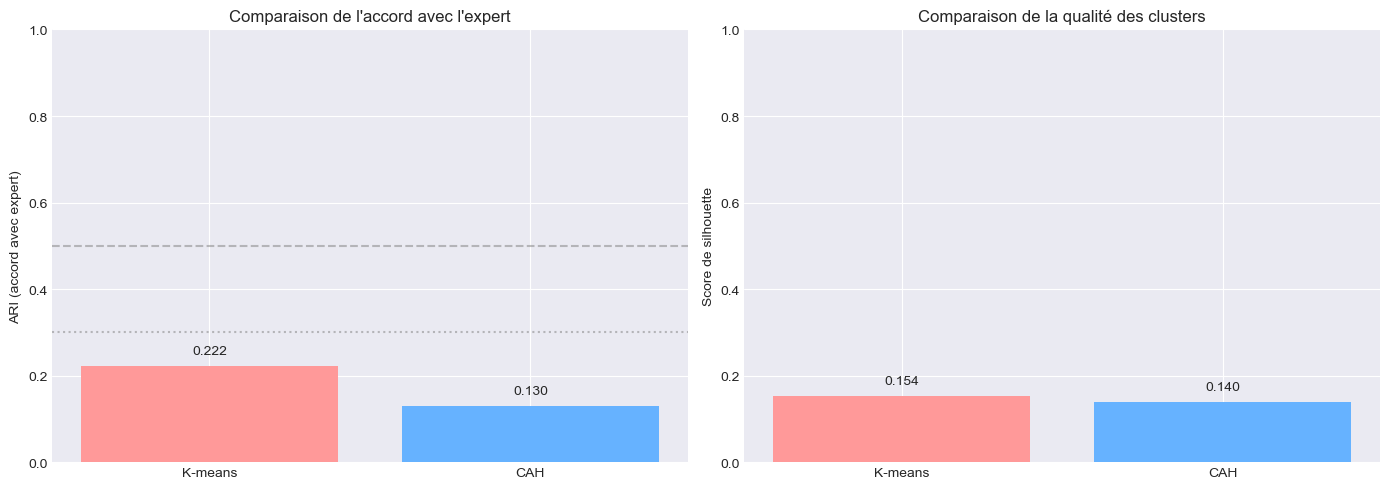

In [ ]:
# ============================================
# ÉTAPE 11 : COMPARAISON FINALE DES MÉTHODES
# ============================================

print("- COMPARAISON DES MÉTHODES DE CLUSTERING :")

# 11.1 Calcul des métriques pour chaque méthode
# K-means
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

# CAH
sil_hier = silhouette_score(X_scaled, hier_labels)

# DBSCAN (si disponible)
if 'best_dbscan_labels' in locals() and best_dbscan_labels is not None:
    mask_db = best_dbscan_labels != -1
    if sum(mask_db) > len(set(best_dbscan_labels[mask_db])) * 2:
        sil_db = silhouette_score(X_scaled[mask_db], best_dbscan_labels[mask_db])
        ari_db = adjusted_rand_score(y_raw[mask_db], best_dbscan_labels[mask_db])
        n_clusters_db = len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)
    else:
        sil_db = 0
        ari_db = 0
        n_clusters_db = 0
else:
    sil_db = 0
    ari_db = 0
    n_clusters_db = 0

# 11.2 Tableau comparatif
print("\n" + "-"*70)
print(f"{'Méthode':<15} {'Nb clusters':<15} {'ARI':<12} {'Silhouette':<15} {'Accord expert'}")
print("-"*70)

# Fonction pour évaluer l'accord
def eval_accord(ari):
    if ari > 0.5: return "- Bon"
    elif ari > 0.3: return "- Modéré"
    else: return "- Faible"

print(f"{'K-means':<15} {best_k:<15} {ari_kmeans:<12.3f} {sil_kmeans:<15.3f} {eval_accord(ari_kmeans)}")
print(f"{'CAH':<15} {best_k:<15} {ari_hier:<12.3f} {sil_hier:<15.3f} {eval_accord(ari_hier)}")

if ari_db > 0:
    print(f"{'DBSCAN':<15} {n_clusters_db:<15} {ari_db:<12.3f} {sil_db:<15.3f} {eval_accord(ari_db)}")
else:
    print(f"{'DBSCAN':<15} {n_clusters_db:<15} {'N/A':<12} {'N/A':<15} {'N/A'}")

print("-"*70)

# 11.3 Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Préparation des données
methods = ['K-means', 'CAH']
aris = [ari_kmeans, ari_hier]
sils = [sil_kmeans, sil_hier]

if ari_db > 0:
    methods.append('DBSCAN')
    aris.append(ari_db)
    sils.append(sil_db)

colors_comp = ['#FF9999', '#66B2FF', '#99FF99']

# Graphique ARI
bars1 = axes[0].bar(methods, aris, color=colors_comp[:len(methods)])
axes[0].set_ylabel('ARI (accord avec expert)')
axes[0].set_title('Comparaison de l\'accord avec l\'expert')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil bon accord')
axes[0].axhline(y=0.3, color='gray', linestyle=':', alpha=0.5, label='Seuil accord modéré')
for i, (bar, v) in enumerate(zip(bars1, aris)):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', 
                 ha='center', va='bottom', fontsize=10)

# Graphique Silhouette
bars2 = axes[1].bar(methods, sils, color=colors_comp[:len(methods)])
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Comparaison de la qualité des clusters')
axes[1].set_ylim([0, 1])
for i, (bar, v) in enumerate(zip(bars2, sils)):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', 
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## **Étape 12 : Conclusion et recommandations finales**

# CONCLUSION GÉNÉRALE DU PROJET

## Traitement et analyse des données

Ce projet visait à évaluer la possibilité de remplacer l'expertise métier 
(classification manuelle des types de peau en 3 catégories) par un système 
automatique basé sur des mesures objectives. Pour cela, nous avons analysé 
un panel de 57 femmes avec 57 variables expérimentales couvrant des aspects 
démographiques, physiologiques, colorimétriques et surtout spectraux.

La méthodologie a suivi un pipeline rigoureux : après nettoyage des données 
et imputation des valeurs manquantes par KNN, nous avons appliqué une 
standardisation, puis une ACP pour visualiser la structure globale. Une 
sélection des variables discriminantes par ANOVA a révélé un résultat majeur : 
**les variables spectrales dominent très largement le classement**, avec des 
F-scores supérieurs à 5 pour les 10 premières, confirmant leur pertinence 
pour caractériser la peau.

Trois algorithmes non supervisés ont été déployés et comparés : K-means, CAH 
et DBSCAN.

## Analyse des résultats obtenus

Les résultats montrent un **accord très faible entre les clusters algorithmiques 
et la classification experte** : ARI de 0,22 pour K-means et 0,13 pour CAH. 
Ces valeurs, proches d'un tirage aléatoire, indiquent que **les groupes 
naturels des données ne correspondent pas aux types de peau définis par 
l'expert**.

Le résultat le plus significatif provient de DBSCAN qui **n'a détecté aucun 
cluster**, quel que soit le paramétrage testé. Cette absence de détection 
est statistiquement cruciale : elle démontre que **les données ne présentent 
pas de groupes naturels distincts**, mais plutôt un continuum où les 
individus se répartissent de façon uniforme.

Autrement dit, la classification experte en 3 types de peau apparaît comme 
une **construction artificielle** qui simplifie une réalité plus complexe. 
Les mesures spectrales, bien que très discriminantes individuellement, 
semblent mesurer des dimensions continues où les frontières entre types 
sont floues, voire inexistantes.

## Suggestions pour améliorer la solution

Face à ces résultats, plusieurs recommandations s'imposent :

**1. Repenser fondamentalement la typologie des peaux**
- Organiser des ateliers avec l'expert pour expliciter ses critères implicites
- Analyser en détail les cas où algorithme et expert divergent
- Envisager un passage à une **représentation continue** (profils multidimensionnels)
 plutôt qu'une classification discrète en 3 catégories

**2. Enrichir la collecte de données**
- Augmenter significativement la taille de l'échantillon (minimum 200 femmes)
- Standardiser les mesures des top variables spectrales identifiées
- Ajouter des données qualitatives (photos, évaluations sensorielles) 
  pour capturer ce que l'expert voit mais que les mesures ne capturent pas

**3. Réorienter la stratégie d'automatisation**
- Abandonner l'idée d'un **remplacement pur** de l'expert
- Développer plutôt un **outil d'aide à la décision** qui combine :
  - Les mesures objectives (scores continus sur les dimensions clés)
  - L'expertise humaine (validation finale)
- Utiliser les résultats pour **enrichir la connaissance métier** :
  "Voici ce que les mesures disent, voici ce que l'expert voit, 
   comment les combiner ?"

**4. Actions immédiates**
- Prototyper un tableau de bord avec les 10 variables spectrales clés
- Former les équipes à leur interprétation
- Mener une étude qualitative approfondie sur 20 femmes représentatives
  pour comprendre l'écart expert-mesures

## Mot de la fin

Ce projet, loin d'être un échec, apporte un **enseignement précieux** : 
la réalité mesurée est plus complexe que la typologie simplifiée utilisée 
par l'expert. Les mesures spectrales sont extrêmement prometteuses, mais 
elles ne remplacent pas le jugement humain - elles le complètent.

La voie à suivre n'est pas l'automatisation pure, mais la **cocréation 
d'une nouvelle connaissance** : utiliser les données pour questionner 
et enrichir l'expertise métier, tout en gardant l'humain au cœur de la 
décision finale. C'est ainsi que l'entreprise pourra développer des 
produits cosmétiques toujours plus personnalisés, basés sur une 
compréhension plus fine et plus objective de la peau.